# Experiment 6: Bagging, Boosting and Stacked Ensembles

Breast cancer dataset again, comparing Bagging, AdaBoost, Gradient Boosting and a stacked ensemble (SVM + Naive Bayes + Decision Tree, Logistic Regression meta-learner).

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

RNG = 42
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

## Load the data

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["diagnosis"] = data.target
df["diagnosis_label"] = df["diagnosis"].map({0: "Malignant", 1: "Benign"})

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Class distribution:\n", df["diagnosis_label"].value_counts())

feature_names = list(data.feature_names)
X = df[feature_names].values
y = df["diagnosis"].values

Dataset shape: (569, 32)
Missing values: 0
Class distribution:
 diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


## Helper functions

In [3]:
def evaluate(y_true, y_pred, y_score=None):
    d = dict(accuracy=accuracy_score(y_true, y_pred),
             precision=precision_score(y_true, y_pred),
             recall=recall_score(y_true, y_pred),
             f1=f1_score(y_true, y_pred))
    if y_score is not None:
        d["roc_auc"] = roc_auc_score(y_true, y_score)
    return d

def train_and_evaluate_classifier(model, X_train, y_train, X_test, y_test):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = model.predict(X_test)
    predict_time = time.perf_counter() - t0
    score = model.predict_proba(X_test)[:, 1]
    metrics = evaluate(y_test, pred, score)
    metrics["train_time"] = train_time
    metrics["predict_time"] = predict_time
    return dict(model=model, pred=pred, score=score, metrics=metrics)

def build_eda_summary_figure(df, feature_names):
    corr = df[feature_names + ["diagnosis"]].corr()["diagnosis"].drop("diagnosis").abs().sort_values(ascending=False)
    top_feats = corr.head(10).index.tolist()

    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    axes = axes.ravel()

    sns.countplot(x="diagnosis_label", data=df, ax=axes[0], hue="diagnosis_label",
                  palette={"Malignant": "indianred", "Benign": "seagreen"}, legend=False)
    axes[0].set_title("Class Distribution")
    axes[0].set_xlabel("Diagnosis"); axes[0].set_ylabel("Count")

    for i, feat in enumerate(top_feats[:6]):
        ax = axes[1 + i]
        for label, color in [("Malignant", "indianred"), ("Benign", "seagreen")]:
            sns.histplot(df.loc[df["diagnosis_label"] == label, feat], bins=25,
                         color=color, alpha=0.55, label=label, ax=ax, kde=False)
        ax.set_title(feat, fontsize=13)
        ax.set_xlabel(feat); ax.set_ylabel("Count")
        if i == 0:
            ax.legend(fontsize=11)

    ax8 = axes[7]
    sns.heatmap(df[top_feats + ["diagnosis"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
                ax=ax8, cbar=False, annot_kws={"size": 7})
    ax8.set_title("Correlation Heatmap (top 10 features)", fontsize=13)
    ax8.tick_params(axis='x', labelsize=7, rotation=90)
    ax8.tick_params(axis='y', labelsize=7)

    for i, feat in enumerate(top_feats[:3]):
        ax = axes[8 + i]
        sns.boxplot(x="diagnosis_label", y=feat, data=df, ax=ax, hue="diagnosis_label",
                    palette={"Malignant": "indianred", "Benign": "seagreen"}, legend=False)
        ax.set_title(feat, fontsize=13)
        ax.set_xlabel("Diagnosis"); ax.set_ylabel(feat)

    ax12 = axes[11]
    for label, color in [("Malignant", "indianred"), ("Benign", "seagreen")]:
        sub = df[df["diagnosis_label"] == label]
        ax12.scatter(sub[top_feats[0]], sub[top_feats[1]], s=14, alpha=0.6, color=color, label=label)
    ax12.set_xlabel(top_feats[0]); ax12.set_ylabel(top_feats[1])
    ax12.set_title(f"{top_feats[0]} vs. {top_feats[1]}", fontsize=13)
    ax12.legend(fontsize=11)

    plt.tight_layout()
    return fig

## EDA

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


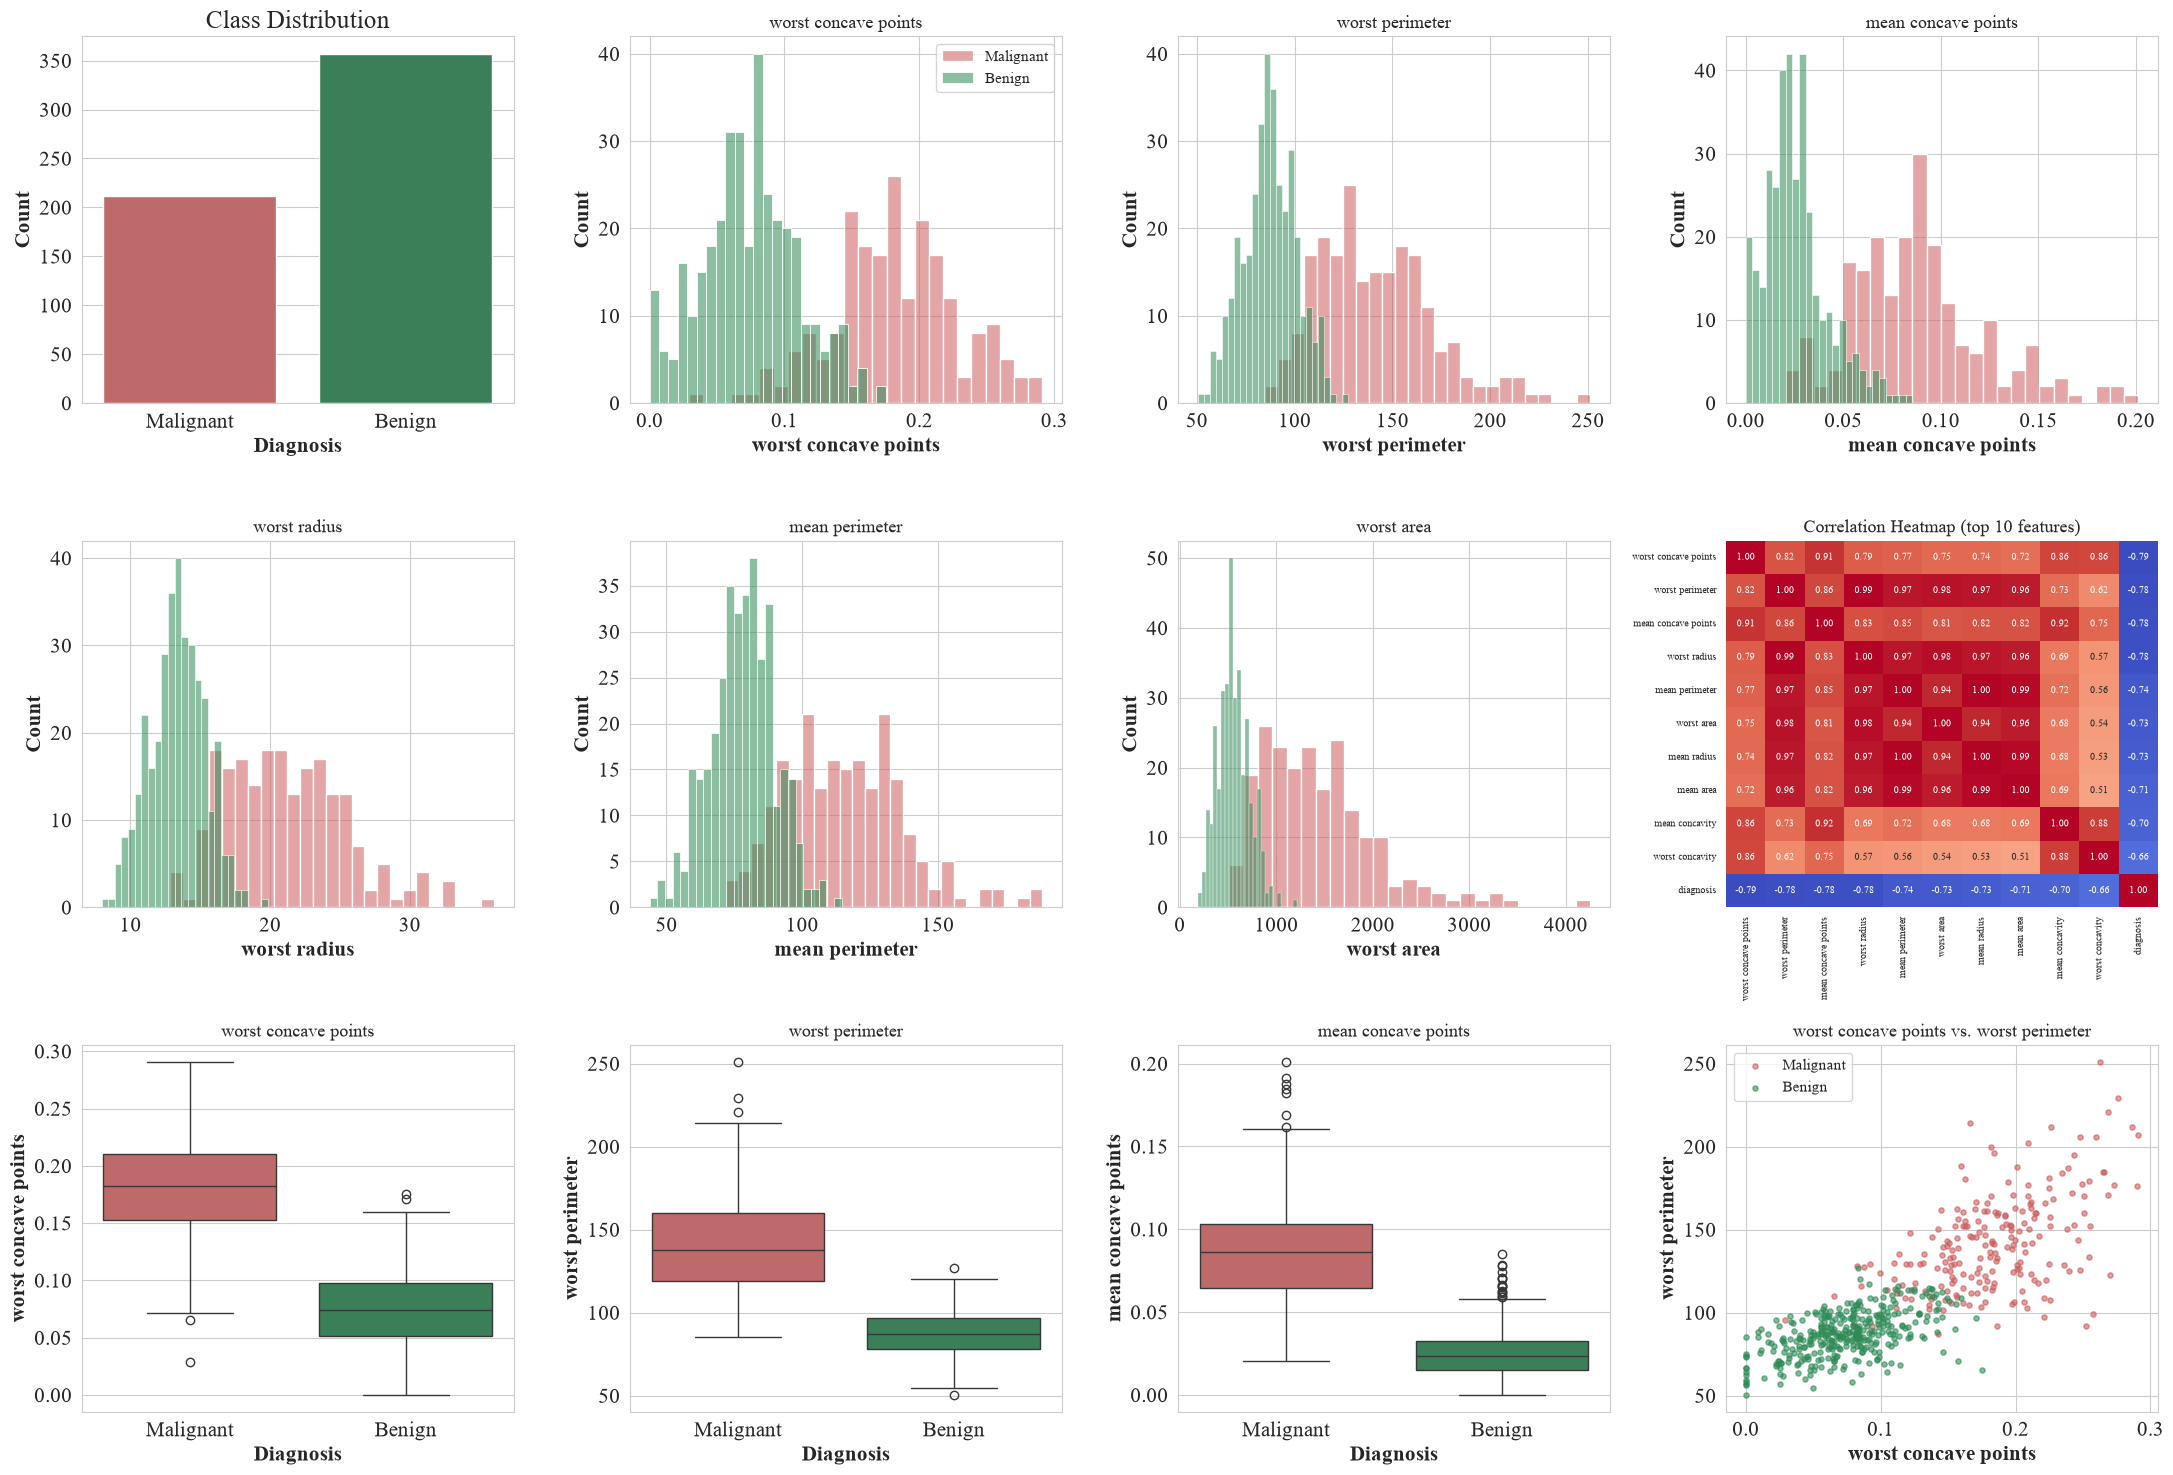

In [4]:
eda_fig = build_eda_summary_figure(df, feature_names)
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)

## Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RNG)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

Train: (455, 30), Test: (114, 30)


## Bagging

In [6]:
bag_param_grid = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0],
}
bag_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RNG), random_state=RNG),
    bag_param_grid, cv=cv5, scoring=["accuracy", "f1"], refit="accuracy", n_jobs=-1)
bag_grid.fit(X_train, y_train)
print("Bagging best params:", bag_grid.best_params_)
print("Bagging best CV accuracy:", bag_grid.best_score_)

bag_tuned = train_and_evaluate_classifier(bag_grid.best_estimator_, X_train, y_train, X_test, y_test)
print("Tuned Bagging (test):", bag_tuned["metrics"])

Bagging best params: {'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 50}
Bagging best CV accuracy: 0.9604395604395606


Tuned Bagging (test): {'accuracy': 0.956140350877193, 'precision': 0.958904109589041, 'recall': 0.9722222222222222, 'f1': 0.9655172413793104, 'roc_auc': 0.9930555555555556, 'train_time': 0.19461370003409684, 'predict_time': 0.008881399990059435}


## AdaBoost

In [7]:
ada_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
}
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=RNG), ada_param_grid,
                         cv=cv5, scoring=["accuracy", "f1"], refit="accuracy", n_jobs=-1)
ada_grid.fit(X_train, y_train)
print("AdaBoost best params:", ada_grid.best_params_)
print("AdaBoost best CV accuracy:", ada_grid.best_score_)

ada_tuned = train_and_evaluate_classifier(ada_grid.best_estimator_, X_train, y_train, X_test, y_test)
print("Tuned AdaBoost (test):", ada_tuned["metrics"])

AdaBoost best params: {'learning_rate': 1.0, 'n_estimators': 100}
AdaBoost best CV accuracy: 0.9802197802197803


Tuned AdaBoost (test): {'accuracy': 0.956140350877193, 'precision': 0.9466666666666667, 'recall': 0.9861111111111112, 'f1': 0.9659863945578231, 'roc_auc': 0.9818121693121693, 'train_time': 0.3925539000192657, 'predict_time': 0.018023099983111024}


## Gradient Boosting

In [8]:
gb_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4],
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=RNG), gb_param_grid,
                        cv=cv5, scoring=["accuracy", "f1"], refit="accuracy", n_jobs=-1)
gb_grid.fit(X_train, y_train)
print("Gradient Boosting best params:", gb_grid.best_params_)
print("Gradient Boosting best CV accuracy:", gb_grid.best_score_)

gb_tuned = train_and_evaluate_classifier(gb_grid.best_estimator_, X_train, y_train, X_test, y_test)
print("Tuned Gradient Boosting (test):", gb_tuned["metrics"])

boost_grid, boost_tuned, boost_name = (
    (ada_grid, ada_tuned, "AdaBoost") if ada_grid.best_score_ >= gb_grid.best_score_
    else (gb_grid, gb_tuned, "Gradient Boosting")
)
print("Boosting model carried forward:", boost_name)

Gradient Boosting best params: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 200}
Gradient Boosting best CV accuracy: 0.9736263736263737


Tuned Gradient Boosting (test): {'accuracy': 0.956140350877193, 'precision': 0.9466666666666667, 'recall': 0.9861111111111112, 'f1': 0.9659863945578231, 'roc_auc': 0.9930555555555556, 'train_time': 0.7669567000120878, 'predict_time': 0.0009668999118730426}
Boosting model carried forward: AdaBoost


## Stacked ensemble

In [9]:
base_learners = [
    ("svm", SVC(probability=True, random_state=RNG)),
    ("nb", GaussianNB()),
    ("dt", DecisionTreeClassifier(random_state=RNG)),
]
stack_param_grid = {
    "final_estimator__C": [0.1, 1, 10],
    "passthrough": [True, False],
}
stack_grid = GridSearchCV(
    StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression(max_iter=2000, random_state=RNG), cv=5),
    stack_param_grid, cv=cv5, scoring=["accuracy", "f1"], refit="accuracy", n_jobs=-1)
stack_grid.fit(X_train, y_train)
print("Stacking best params:", stack_grid.best_params_)
print("Stacking best CV accuracy:", stack_grid.best_score_)

stack_tuned = train_and_evaluate_classifier(stack_grid.best_estimator_, X_train, y_train, X_test, y_test)
print("Tuned Stacking (test):", stack_tuned["metrics"])

Stacking best params: {'final_estimator__C': 1, 'passthrough': True}
Stacking best CV accuracy: 0.9516483516483516


Tuned Stacking (test): {'accuracy': 0.9649122807017544, 'precision': 0.9594594594594594, 'recall': 0.9861111111111112, 'f1': 0.9726027397260274, 'roc_auc': 0.9957010582010581, 'train_time': 1.0513938999501988, 'predict_time': 0.0039003000129014254}


## 5-fold CV comparison

In [10]:
bag_cv = cross_val_score(bag_grid.best_estimator_, X_train, y_train, cv=cv5, scoring="accuracy")
boost_cv = cross_val_score(boost_grid.best_estimator_, X_train, y_train, cv=cv5, scoring="accuracy")
stack_cv = cross_val_score(stack_grid.best_estimator_, X_train, y_train, cv=cv5, scoring="accuracy")

print("Bagging CV:", bag_cv, "mean:", bag_cv.mean())
print(f"{boost_name} CV:", boost_cv, "mean:", boost_cv.mean())
print("Stacking CV:", stack_cv, "mean:", stack_cv.mean())

Bagging CV: [0.95604396 0.95604396 0.93406593 0.96703297 0.98901099] mean: 0.9604395604395606
AdaBoost CV: [0.98901099 1.         0.94505495 0.97802198 0.98901099] mean: 0.9802197802197803
Stacking CV: [0.98901099 0.93406593 0.94505495 0.94505495 0.94505495] mean: 0.9516483516483516


## Hyperparameter sweep tables

In [11]:
bag_res = pd.DataFrame(bag_grid.cv_results_)
bag_sweep = bag_res[bag_res["param_max_features"] == bag_grid.best_params_["max_features"]][
    ["param_n_estimators", "param_max_samples", "mean_test_accuracy", "mean_test_f1"]]
bag_sweep.columns = ["n_estimators", "max_samples", "avg_cv_accuracy", "avg_cv_f1"]
print("Bagging sweep (max_features={} fixed):".format(bag_grid.best_params_["max_features"]))
print(bag_sweep.to_string(index=False))

boost_res = pd.DataFrame(boost_grid.cv_results_)
if boost_name == "AdaBoost":
    boost_sweep = boost_res[["param_n_estimators", "param_learning_rate", "mean_test_accuracy", "mean_test_f1"]]
    boost_sweep.columns = ["n_estimators", "learning_rate", "avg_cv_accuracy", "avg_cv_f1"]
else:
    boost_sweep = boost_res[boost_res["param_max_depth"] == boost_grid.best_params_["max_depth"]][
        ["param_n_estimators", "param_learning_rate", "mean_test_accuracy", "mean_test_f1"]]
    boost_sweep.columns = ["n_estimators", "learning_rate", "avg_cv_accuracy", "avg_cv_f1"]
print(f"\n{boost_name} sweep:")
print(boost_sweep.to_string(index=False))

stack_res = pd.DataFrame(stack_grid.cv_results_)
stack_sweep = stack_res[["param_final_estimator__C", "param_passthrough", "mean_test_accuracy", "mean_test_f1"]]
stack_sweep.columns = ["final_estimator_C", "passthrough", "avg_cv_accuracy", "avg_cv_f1"]
print("\nStacking sweep:")
print(stack_sweep.to_string(index=False))

Bagging sweep (max_features=0.5 fixed):
 n_estimators  max_samples  avg_cv_accuracy  avg_cv_f1
           10          0.5         0.951648   0.961019
           50          0.5         0.960440   0.968138
          100          0.5         0.953846   0.962975
           10          0.7         0.949451   0.959370
           50          0.7         0.958242   0.966520
          100          0.7         0.960440   0.968288
           10          1.0         0.956044   0.964839
           50          1.0         0.960440   0.968325
          100          1.0         0.960440   0.968418

AdaBoost sweep:
 n_estimators  learning_rate  avg_cv_accuracy  avg_cv_f1
           50           0.01         0.925275   0.940745
          100           0.01         0.934066   0.947975
          200           0.01         0.936264   0.949600
           50           0.10         0.953846   0.963289
          100           0.10         0.960440   0.968602
          200           0.10         0.971429   0.9

## Confusion matrices

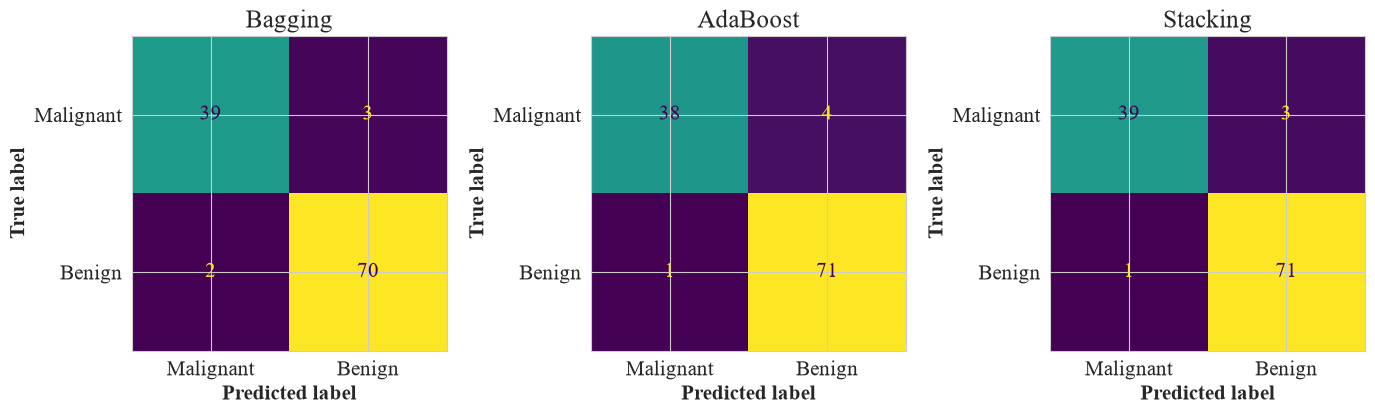

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, bag_tuned["pred"]),
                        display_labels=["Malignant", "Benign"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Bagging")
ConfusionMatrixDisplay(confusion_matrix(y_test, boost_tuned["pred"]),
                        display_labels=["Malignant", "Benign"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title(boost_name)
ConfusionMatrixDisplay(confusion_matrix(y_test, stack_tuned["pred"]),
                        display_labels=["Malignant", "Benign"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Stacking")
plt.tight_layout()
plt.savefig("figures/01_confusion_matrices.png", dpi=150)
plt.show()
plt.close()

## ROC curves

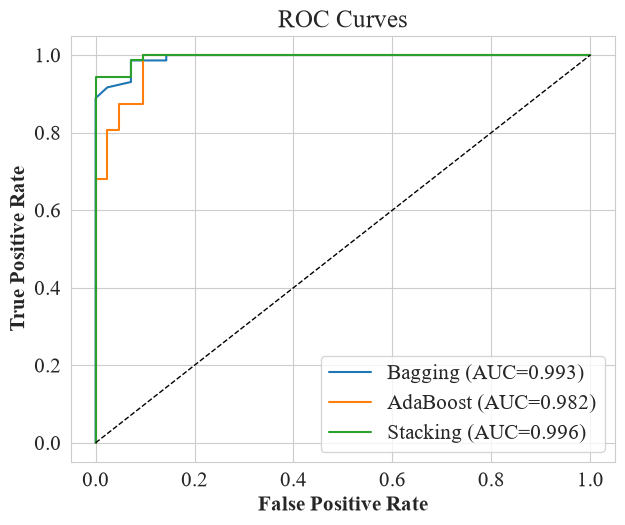

In [13]:
plt.figure(figsize=(6.5, 5.5))
for name, score in [("Bagging", bag_tuned["score"]), (boost_name, boost_tuned["score"]), ("Stacking", stack_tuned["score"])]:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, score):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend()
plt.tight_layout()
plt.savefig("figures/02_roc_curves.png", dpi=150)
plt.show()
plt.close()

## CV fold comparison

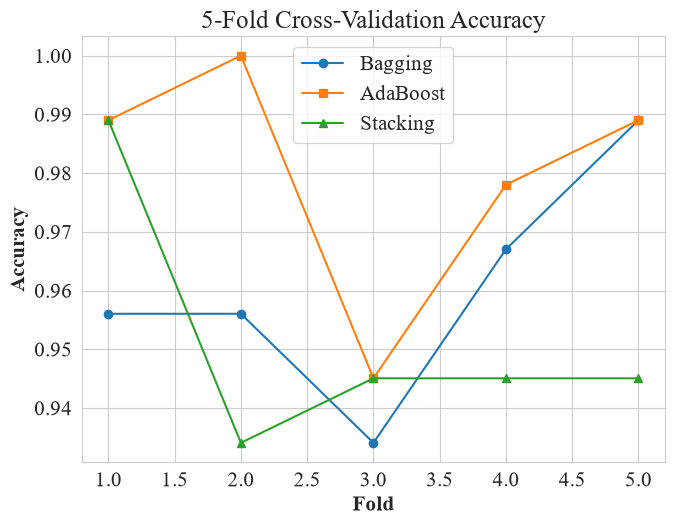

In [14]:
plt.figure(figsize=(7, 5.5))
folds = np.arange(1, 6)
plt.plot(folds, bag_cv, marker="o", label="Bagging")
plt.plot(folds, boost_cv, marker="s", label=boost_name)
plt.plot(folds, stack_cv, marker="^", label="Stacking")
plt.xlabel("Fold"); plt.ylabel("Accuracy"); plt.title("5-Fold Cross-Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("figures/03_cv_fold_comparison.png", dpi=150)
plt.show()
plt.close()

## Metric comparison

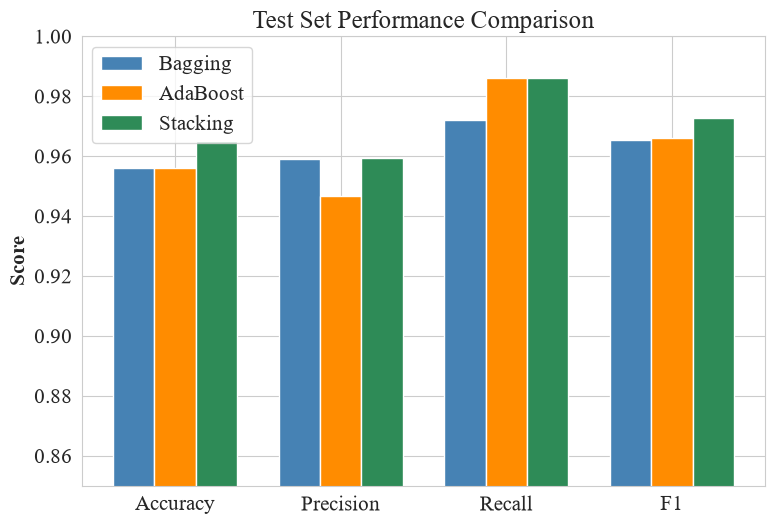

In [15]:
plt.figure(figsize=(8, 5.5))
metric_names = ["accuracy", "precision", "recall", "f1"]
bag_vals = [bag_tuned["metrics"][m] for m in metric_names]
boost_vals = [boost_tuned["metrics"][m] for m in metric_names]
stack_vals = [stack_tuned["metrics"][m] for m in metric_names]
x = np.arange(len(metric_names)); w = 0.25
plt.bar(x - w, bag_vals, width=w, label="Bagging", color="steelblue")
plt.bar(x, boost_vals, width=w, label=boost_name, color="darkorange")
plt.bar(x + w, stack_vals, width=w, label="Stacking", color="seagreen")
plt.xticks(x, [m.capitalize() for m in metric_names])
plt.ylim(0.85, 1.0); plt.ylabel("Score")
plt.title("Test Set Performance Comparison"); plt.legend()
plt.tight_layout()
plt.savefig("figures/04_model_comparison.png", dpi=150)
plt.show()
plt.close()

## Bagging hyperparameter heatmap

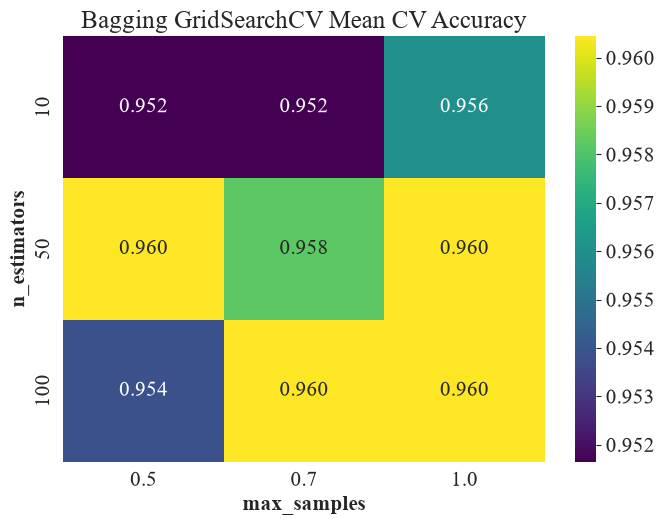

In [16]:
bag_pivot = bag_res.pivot_table(values="mean_test_accuracy", index="param_n_estimators",
                                 columns="param_max_samples", aggfunc="max")
plt.figure(figsize=(7, 5.5))
sns.heatmap(bag_pivot, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("max_samples"); plt.ylabel("n_estimators")
plt.title("Bagging GridSearchCV Mean CV Accuracy")
plt.tight_layout()
plt.savefig("figures/05_bagging_gridsearch_heatmap.png", dpi=150)
plt.show()
plt.close()

## Save results

In [17]:
with open("results_summary.txt", "w") as f:
    f.write(f"Dataset shape: {df.shape}\n")
    f.write(f"Class distribution: {df['diagnosis_label'].value_counts().to_dict()}\n\n")

    f.write(f"Bagging best params: {bag_grid.best_params_}\n")
    f.write(f"Bagging best CV accuracy: {bag_grid.best_score_:.4f}\n")
    f.write(f"Tuned Bagging test metrics: {bag_tuned['metrics']}\n\n")

    f.write(f"AdaBoost best params: {ada_grid.best_params_}\n")
    f.write(f"AdaBoost best CV accuracy: {ada_grid.best_score_:.4f}\n")
    f.write(f"Tuned AdaBoost test metrics: {ada_tuned['metrics']}\n\n")

    f.write(f"Gradient Boosting best params: {gb_grid.best_params_}\n")
    f.write(f"Gradient Boosting best CV accuracy: {gb_grid.best_score_:.4f}\n")
    f.write(f"Tuned Gradient Boosting test metrics: {gb_tuned['metrics']}\n\n")

    f.write(f"Boosting model carried forward: {boost_name}\n\n")

    f.write(f"Stacking best params: {stack_grid.best_params_}\n")
    f.write(f"Stacking best CV accuracy: {stack_grid.best_score_:.4f}\n")
    f.write(f"Tuned Stacking test metrics: {stack_tuned['metrics']}\n\n")

    f.write(f"Bagging 5-fold CV: {bag_cv.tolist()} mean={bag_cv.mean():.4f} std={bag_cv.std():.4f}\n")
    f.write(f"{boost_name} 5-fold CV: {boost_cv.tolist()} mean={boost_cv.mean():.4f} std={boost_cv.std():.4f}\n")
    f.write(f"Stacking 5-fold CV: {stack_cv.tolist()} mean={stack_cv.mean():.4f} std={stack_cv.std():.4f}\n\n")

    f.write("Bagging sweep:\n" + bag_sweep.to_string(index=False) + "\n\n")
    f.write(f"{boost_name} sweep:\n" + boost_sweep.to_string(index=False) + "\n\n")
    f.write("Stacking sweep:\n" + stack_sweep.to_string(index=False) + "\n")

print("Done.")

Done.
